In [2]:
#!pip install -qU "langgraph>=0.5.0", "langsmith>=0.4.4"

In [3]:
import os
import getpass

from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

### building

In [4]:
from langgraph.graph import START, StateGraph
from typing_extensions import TypedDict
from langchain_core.documents import Document

class State(TypedDict):
  question: str
  context: list[Document]
  response: str

In [5]:
# just for the notebook to work

import nest_asyncio

nest_asyncio.apply()

### load the documents for the knowledge base

In [6]:
from langchain_community.document_loaders import DirectoryLoader
from langchain_community.document_loaders import PyMuPDFLoader

directory_loader = DirectoryLoader("data", glob="**/*.pdf", loader_cls=PyMuPDFLoader)

loan_knowledge_resources = directory_loader.load()

In [7]:
loan_knowledge_resources[0].page_content[:200]

'Volume 7\nThe Federal Pell Grant Program\nIntroduction\nThis volume of the Federal Student Aid Handbook provides information to assist schools in determining student eligibility\nfor and calculating the a'

In [8]:
import tiktoken
from langchain.text_splitter import RecursiveCharacterTextSplitter

def tiktoken_len(text):
    tokens = tiktoken.encoding_for_model("gpt-4o").encode(
        text,
    )
    return len(tokens)

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 750,
    chunk_overlap = 0,
    length_function = tiktoken_len,
)

In [9]:
loan_knowledge_chunks = text_splitter.split_documents(loan_knowledge_resources)

In [10]:
from langchain_openai.embeddings import OpenAIEmbeddings

embedding_model = OpenAIEmbeddings(model="text-embedding-3-small")

In [11]:
embedding_dim =  1536

In [12]:
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient
from qdrant_client.http.models import Distance, VectorParams

client = QdrantClient(":memory:")

In [13]:
client.create_collection(
    collection_name="loan_knowledge_index",
    vectors_config=VectorParams(size=embedding_dim, distance=Distance.COSINE),
)

True

In [14]:
vector_store = QdrantVectorStore(
    client=client,
    collection_name="loan_knowledge_index",
    embedding=embedding_model,
)

In [15]:
_ = vector_store.add_documents(documents=loan_knowledge_chunks)

In [16]:
retriever = vector_store.as_retriever(search_kwargs={"k": 5})

In [17]:
retriever.invoke("Is applying for and securing a student loan in 2025 a terrible idea?")

[Document(metadata={'producer': 'GPL Ghostscript 10.00.0', 'creator': 'wkhtmltopdf 0.12.6', 'creationdate': "D:20250605165703Z00'00'", 'source': 'data/The_Direct_Loan_Program.pdf', 'file_path': 'data/The_Direct_Loan_Program.pdf', 'total_pages': 71, 'format': 'PDF 1.7', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': "D:20250605165703Z00'00'", 'trapped': '', 'modDate': "D:20250605165703Z00'00'", 'creationDate': "D:20250605165703Z00'00'", 'page': 64, '_id': '67c14a946e2945c4b559d599048f85b2', '_collection_name': 'loan_knowledge_index'}, page_content='student to earn that number of credits. For instance, if your school has a baccalaureate program that requires 120\nsemester hours of work and is typically completed in four academic years, then you might use a standard of 30 hours\ncompleted at each grade level.\nStandard Term and SE9W Nonstandard Term Programs: Grade Level Progression Within the Same Academic Year\nIn standard term programs or SE9W nonstandard term pro

In [34]:
def retrieve(state: State) -> State:
  retrieved_docs = retriever.invoke(state["question"])
  return {"context" : retrieved_docs}

In [35]:
from langchain_core.prompts import ChatPromptTemplate

HUMAN_TEMPLATE = """
#CONTEXT:
{context}

QUERY:
{query}

Use the provide context to answer the provided user query. Only use the provided context to answer the query. If you do not know the answer, or it's not contained in the provided context response with "I don't know"
"""

chat_prompt = ChatPromptTemplate.from_messages([
    ("human", HUMAN_TEMPLATE)
])

In [36]:
chat_prompt.invoke({"context" : "OUR CONTEXT HERE", "query" : "OUR QUERY HERE"}).messages[0].content

'\n#CONTEXT:\nOUR CONTEXT HERE\n\nQUERY:\nOUR QUERY HERE\n\nUse the provide context to answer the provided user query. Only use the provided context to answer the query. If you do not know the answer, or it\'s not contained in the provided context response with "I don\'t know"\n'

In [37]:
from langchain_openai import ChatOpenAI

openai_chat_model = ChatOpenAI(model="gpt-4.1-nano")

In [39]:
openai_chat_model.invoke(chat_prompt.invoke({"context" : "The Capital of France is Paris", "query" : "What is the capital of France?"}))

AIMessage(content='The capital of France is Paris.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 7, 'prompt_tokens': 72, 'total_tokens': 79, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-nano-2025-04-14', 'system_fingerprint': None, 'id': 'chatcmpl-BtqApiBf8TTQ4gUWWMuWtP6A5nQxc', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--7ea2ce46-31ad-499e-8de2-114fa86ba25a-0', usage_metadata={'input_tokens': 72, 'output_tokens': 7, 'total_tokens': 79, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [23]:
from langchain_core.output_parsers import StrOutputParser

generator_chain = chat_prompt | openai_chat_model | StrOutputParser()

generator_chain.invoke({"context" : "Applying for and securing a student loan in 2025 is a terrible idea", "query" : "What is the capital of France?"})

"I don't know"

In [24]:
def generate(state: State) -> State:
  generator_chain = chat_prompt | openai_chat_model | StrOutputParser()
  response = generator_chain.invoke({"query" : state["question"], "context" : state["context"]})
  return {"response" : response}

In [25]:
# Start with the blank canvas
graph_builder = StateGraph(State)

In [26]:
graph_builder = graph_builder.add_sequence([retrieve, generate])

In [27]:
graph_builder.add_edge(START, "retrieve")

In [28]:
graph = graph_builder.compile()

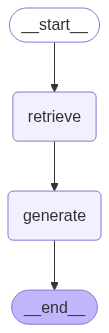

In [29]:
graph

In [30]:
from IPython.display import Markdown, display
response = graph.invoke({"question" : "Is applying for and securing a student loan in 2025 a terrible idea?"})
display(Markdown(response["response"]))

Applying for and securing a student loan in 2025 is not necessarily a terrible idea based on the provided context. The documents outline processes for determining eligibility, counseling requirements, deadlines, and how to manage loan amounts and limits. These details suggest that with proper understanding and planning, taking out a student loan can be a manageable part of financing education. However, whether it is a good or bad idea depends on individual circumstances and how the loans are used and repaid, which is not directly addressed in the provided context.

In [31]:
response = graph.invoke({"question" : "How much loan money can I actually get from the government to go to school these days? Is there a cap?"})
display(Markdown(response["response"]))

Based on the provided context, the maximum loan amount a student may receive from the government varies depending on the program and individual circumstances. For example, a dependent first-year undergraduate student has a combined annual loan limit of $5,500, with no more than $3,500 of that amount being subsidized. A dependent second-year undergraduate student can receive up to a $6,500 annual limit, with no more than $4,500 subsidized. 

There are also aggregate loan limits for different types of students:
- For dependent undergraduates (excluding those whose parents can't get Direct PLUS Loans), the total maximum subsidized and unsubsidized loans are up to $31,000, with no more than $23,000 subsidized.
- For independent undergraduates, the total can go up to $57,500, with no more than $23,000 subsidized.
- Graduate and professional students have a combined total limit of $138,500, with no more than $65,500 subsidized.

Additionally, for programs shorter than an academic year or involving changes in grade level during the year, the amount you can borrow may be prorated based on the hours or weeks of enrollment.

In summary, yes, there are caps on how much loan money you can receive from the government, and these limits depend on your enrollment status, year in school, and whether your program is full-term or shorter.

In [32]:
response = graph.invoke({"question" : "What grants and scholarships are available for free?"})
display(Markdown(response["response"]))

Based on the provided context, grants and scholarships available for free include Pell Grants, FSEOG (Federal Supplementary Educational Opportunity Grants), State grants, and other scholarships such as athletic scholarships and scholarships that require future employment. These aid types do not require repayment and are considered free financial assistance.

In [33]:
response = graph.invoke({"question" : "Who is Batman?"})
display(Markdown(response["response"]))

I don't know